# Load DPC data files and make top level statistics

In [ ]:
import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None 
import pickle

import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from matplotlib.ticker import MultipleLocator

## (1) load pickle file duopoly_feedback.data
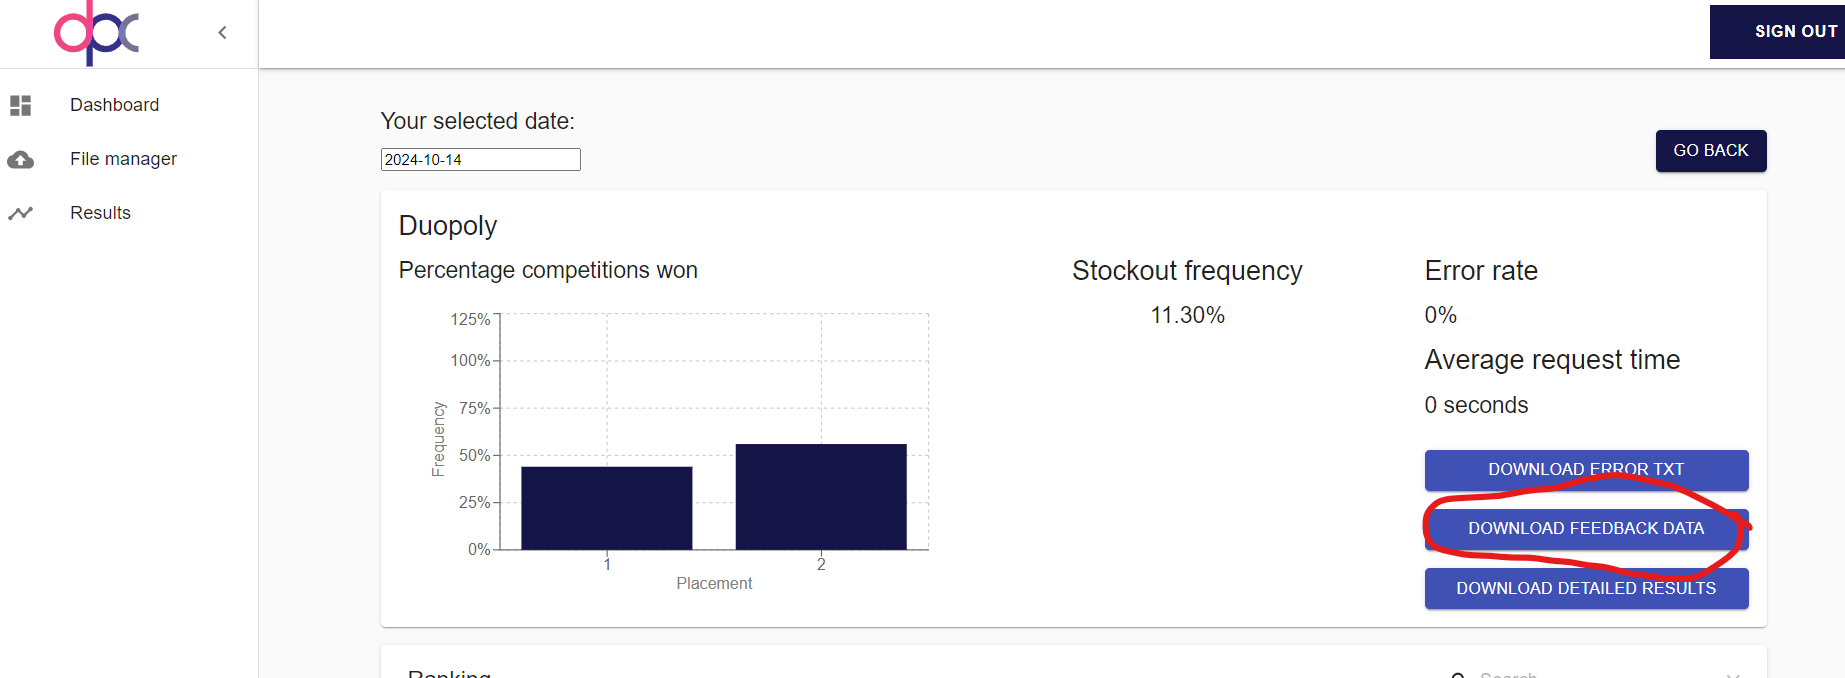

In [ ]:
with open('duopoly_feedback.data', 'rb') as handle:
    feedback = pickle.load(handle)

In [ ]:
feedback.keys()

In [ ]:
feedback['history'].head(10)

In [ ]:
feedback['current_simulation']

In [ ]:
feedback['cumulative_revenue_current_selling_season']

## (2) load duopoly_competition_details.csv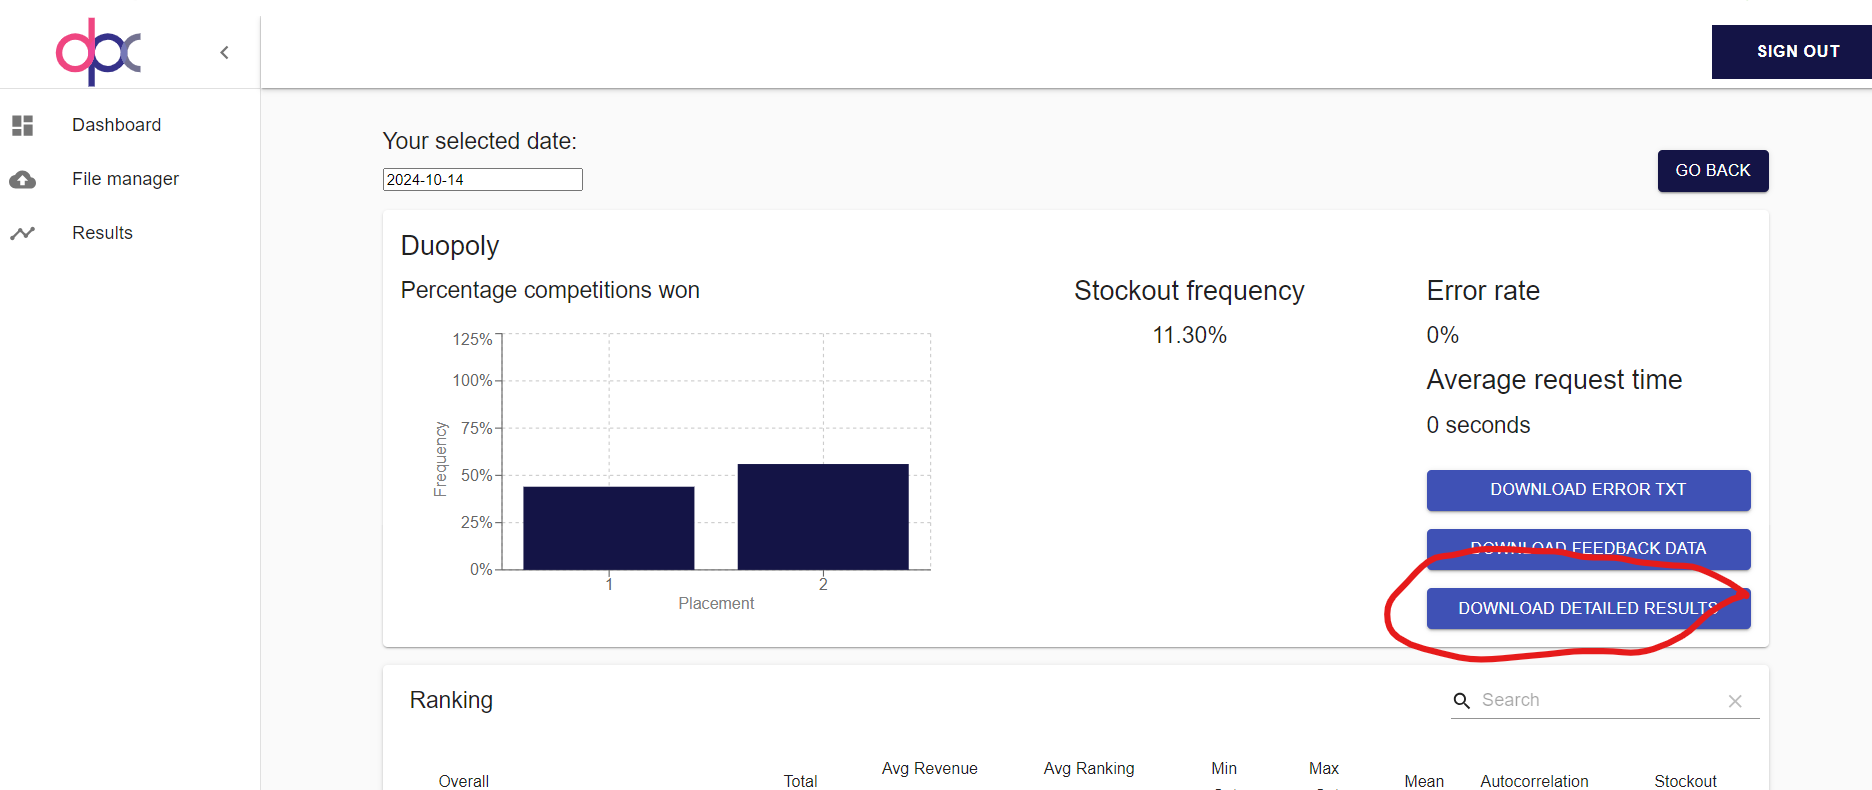

In [ ]:
df_comp_details = pd.read_csv('duopoly_competition_details.csv')
df_comp_details.head(10)

In [ ]:
df_comp_details.groupby('competitor_id').agg({
    'competition_id' : 'nunique',
    'selling_season' : ['max', 'count']
})

### create unique selling_season_id

In [ ]:
df_comp_details['unique_selling_season_key'] = df_comp_details.apply(lambda r:
                                "%s_%s" % (r.competition_id,r.selling_season), axis=1)

df_comp_details.head(3)

#### show revenue distribution over all selling seasons

In [ ]:
df_comp_details['revenue'] = df_comp_details['demand'] * df_comp_details['price']

In [ ]:
dfx_rev = df_comp_details.groupby('unique_selling_season_key').agg({
    'revenue' : 'sum'
}).reset_index()

dfx_rev.head()

In [ ]:
dfx_rev.hist()

In [ ]:
dfx_rev_top = dfx_rev.sort_values('revenue', ascending=False)

dfx_rev_top.head(10)

### visualize the results of one selling season

In [ ]:
id = dfx_rev_top['unique_selling_season_key'].values[1]

df_aux = df_comp_details[df_comp_details.unique_selling_season_key==id]
df_aux.head(10)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

ax.bar(df_aux.selling_period, df_aux.demand, color='b', width=0.6, align='center', label = 'sold seats')
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("sold seats" , size=11)

ax_2 = ax.twinx()
ax_2.grid(False)
ax_2.plot(df_aux.selling_period, df_aux.price, color='g', linestyle='-', linewidth=3, label = 'my price')
ax_2.plot(df_aux.selling_period, df_aux.price_competitor, color='r', linestyle='-', linewidth=3, label = 'competitor price')
ax_2.tick_params(axis="both", labelsize=10)
ax_2.set_ylabel("prices" , size=11)

ax.tick_params(axis="both", labelsize=10)
ax.set_title("realization of first selling season", size=12)

# legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax_2.get_legend_handles_labels()
ax_2.legend(lines + lines2, labels + labels2, loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()

# Plot the Capacity Utilization Curve

**capacity utilization = sold quantity / capacity**

In [ ]:
df_aux['cum_demand'] = df_aux['demand'].cumsum()
df_aux['cap_util'] = round(df_aux[ 'cum_demand'] / 80 ,2)
df_aux.tail(5)

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

# ax.plot(df_aux.selling_period, df_aux.cum_demand, color='b', 
#        width=0.6, align='center', label = 'sold seats')
ax.plot(df_aux.selling_period, df_aux.cap_util, color='g', 
        linestyle='-', linewidth=3, label = 'capacity utilization')
ax.set_xlabel('selling_periods', size=11)
# ax.set_xticks(np.arange(min(dft.index), max(dft.index)+1, 1.0))
ax.set_ylabel("capacity utilization" , size=11)

y_majorLocator = MultipleLocator(0.1)
ax.yaxis.set_major_locator(y_majorLocator)
x_majorLocator = MultipleLocator(10)
ax.xaxis.set_major_locator(x_majorLocator)

ax.set_title("show capacity utilization (cumulative sales) over time", size=12)
# ax.legend(loc=0)

ax.grid(True)
fig.tight_layout()

plt.show()